In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import pandas as pd 
import numpy as np 
from pathlib import Path
import warnings
from scipy.stats import friedmanchisquare
warnings.filterwarnings("ignore") 
from functools import reduce
from scikit_posthocs import posthoc_nemenyi_friedman

In [3]:

DATA_DIR = Path("/Users/mlin2/Desktop/RabLab/tasks/concurrent/data/cleaned_dat")

# clean bl
dat_bl = pd.read_csv(DATA_DIR / "merged_baseline_wDemo.csv")
dat_bl = dat_bl[dat_bl.dx.isin(["EOAD","EOnonAD"])]
eoad_ids = dat_bl[dat_bl.dx=="EOAD"].subject_label.tolist()

# clean long
def exclude_tx(df):
    return df[df.tx_started == 0].drop(
        columns=["tx_start_date", "tx_started"]
    ) 
def filter_longitudinal(df, eoad_ids, id_col="subject_label"):
    # eoad IDs
    df = df[df[id_col].isin(eoad_ids)].copy()

    # >=2 tps
    valid_ids = (
        df[id_col]
        .value_counts()
        .loc[lambda x: x >= 2]
        .index
    )

    return df[df[id_col].isin(valid_ids)].copy()
long_byptau = pd.read_csv(DATA_DIR / "ptau_ref_long_only_eoad_90d.csv")

ptau_final = exclude_tx(pd.read_csv(DATA_DIR / "ptau_cleaned_20260418.csv"))
tau_final  = exclude_tx(pd.read_csv(DATA_DIR / "tau_cleaned_20260418.csv"))
amy_final  = exclude_tx(pd.read_csv(DATA_DIR / "amy_cleaned_20260418.csv"))
cdr_final  = exclude_tx(pd.read_csv(DATA_DIR / "cdr_cleaned_20260418.csv"))
moca_final = exclude_tx(pd.read_csv(DATA_DIR / "moca_cleaned_20260418.csv"))
ptau_final = filter_longitudinal(ptau_final, eoad_ids)
tau_final  = filter_longitudinal(tau_final,  eoad_ids)
amy_final  = filter_longitudinal(amy_final,  eoad_ids)
cdr_final  = filter_longitudinal(cdr_final,  eoad_ids)
moca_final = filter_longitudinal(moca_final, eoad_ids)
ptau_final["log_ptau217"] = np.log(ptau_final["ptau217"]) 
long_byptau["log_ptau217"] = np.log(long_byptau["ptau217"]) 
dat_bl["log_ptau217"] = np.log(dat_bl["ptau217"]) 

In [4]:

# --- define expected columns ---
expected_cols = {
    "ptau_final": ["log_ptau217", "day_to_baseline_ptau"],
    "tau_final": ["desikan_suvr", "day_to_baseline_tau"],
    "amy_final": ["centiloid_wcbl", "day_to_baseline_amy"],
    "cdr_final": ["cdrsb", "day_to_baseline_cdr"],
    "moca_final": ["moca", "day_to_baseline_moca"],
}


# --- check columns exist ---
for df_name, cols in expected_cols.items():
    df = globals().get(df_name)
    if df is None:
        raise ValueError(f"{df_name} not found in environment")

    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"{df_name} is missing columns: {missing}")
    else:
        print(f"{df_name}: all required columns present")
 

ptau_final: all required columns present
tau_final: all required columns present
amy_final: all required columns present
cdr_final: all required columns present
moca_final: all required columns present


In [5]:
biomarkers = ["ptau217","desikan_suvr","centiloid_wcbl"]
cogs = ["moca","cdrsb"]

# validity (baseline clinical differentiation between EOAD and EOnonAD)
operationalized as difference between each group's deviation from the global mean


In [6]:
from utils.stats_utils import pooled_sd 
from scipy.stats import ttest_ind
#take two lists and output the pooled sd 

In [7]:
def compute_diff_effect(df, biomarker, group_col="dx", group_order=None, sf=3):
    g = df[[biomarker, group_col]].dropna().copy()

    if group_order is None:
        group_order = list(pd.Series(g[group_col].unique()).sort_values())
    if len(group_order) != 2:
        raise ValueError(f"{group_col} must have exactly 2 groups.")

    g1, g2 = group_order
    x1 = g.loc[g[group_col] == g1, biomarker].values
    x2 = g.loc[g[group_col] == g2, biomarker].values

    sp = pooled_sd(x1, x2)
    d = abs(np.mean(x1) - np.mean(x2)) / sp

    return round(d, sf)
 

In [8]:
def compute_diff_W(df, biomarkers, group_col="dx", id_col="subject_label", sf=3):
    W_dfs = []
    summary_rows = []

    # fix group order so results are stable
    groups = list(pd.Series(df[group_col].dropna().unique()).sort_values())
    if len(groups) != 2:
        raise ValueError(f"{group_col} must have exactly 2 groups.")
    g1, g2 = groups

    for biomarker in biomarkers:
            
        d = df[[id_col, biomarker, group_col]].dropna().copy()

        if biomarker == "moca":
            d[biomarker] = -d[biomarker]

        x1 = d.loc[d[group_col] == g1, biomarker].astype(float).values
        x2 = d.loc[d[group_col] == g2, biomarker].astype(float).values

        n1, n2 = len(x1), len(x2)
        m1, m2 = np.mean(x1), np.mean(x2)
        s1, s2 = np.std(x1, ddof=1), np.std(x2, ddof=1)

        sp = pooled_sd(x1, x2)
        d_eff = abs(m1 - m2) / sp if sp and not np.isnan(sp) else np.nan

        # p value for group comparison on the raw biomarker
        # inside your loop, after computing x1, x2
        _, pval = ttest_ind(x1, x2, equal_var=False, nan_policy="omit")

        summary_rows.append({
            "biomarker": biomarker,
            f"{g1}_n": n1,
            f"{g1}_mean": round(m1, sf),
            f"{g1}_sd": round(s1, sf),
            f"{g2}_n": n2,
            f"{g2}_mean": round(m2, sf),
            f"{g2}_sd": round(s2, sf),
            "effect_size_d": round(d_eff, sf),
            "p_value": pval
        })
        biomarker_mean = d[biomarker].mean()
        group_N = d[group_col].value_counts().to_dict()

        group_map = {g1: 1, g2: 2}

        def compute_row(row):
            k = group_map[row[group_col]]
            nk = group_N[row[group_col]]
            sign = (-1) ** (k - 1)
            return sign * (row[biomarker] - biomarker_mean) / nk / sp

        d[biomarker] = d.apply(compute_row, axis=1)
        W_dfs.append(d[[id_col, biomarker]])

    W_mat = reduce(lambda left, right: pd.merge(left, right, on=id_col), W_dfs)
    summary_table = pd.DataFrame(summary_rows)
    summary_table["p_value"] = summary_table["p_value"].apply(lambda x: f"{x:.4g}")

    return W_mat, summary_table
    

## between EOnonAD and EOAD

In [9]:
W_mat, summary_table = compute_diff_W(dat_bl, biomarkers+cogs)

arrays = [W_mat[b].values for b in biomarkers+cogs]
stat, p = friedmanchisquare(*arrays)
print(f"Friedman test statistic: {stat:.4f}")
print(f"p-value: {p:.4e}") 

print("\nRanking average W (larger = better)")
print(dict(W_mat[biomarkers+cogs].mean().sort_values(ascending=False)))

posthoc = posthoc_nemenyi_friedman(W_mat[biomarkers+cogs])
print("\nPost hoc (Nemenyi) p-values:")
print(posthoc.round(4))


Friedman test statistic: 250.8091
p-value: 4.3578e-53

Ranking average W (larger = better)
{'centiloid_wcbl': 0.006976432133942629, 'ptau217': 0.0035417091563519037, 'desikan_suvr': 0.0034732014618569533, 'moca': 0.0023277060608552407, 'cdrsb': 0.0012489427727618724}

Post hoc (Nemenyi) p-values:
                ptau217  desikan_suvr  centiloid_wcbl    moca   cdrsb
ptau217          1.0000        0.9979             0.0  0.0179  0.0000
desikan_suvr     0.9979        1.0000             0.0  0.0456  0.0000
centiloid_wcbl   0.0000        0.0000             1.0  0.0000  0.0000
moca             0.0179        0.0456             0.0  1.0000  0.0738
cdrsb            0.0000        0.0000             0.0  0.0738  1.0000


In [10]:
print("\nTable of group summaries and effect sizes:")

nice_table = summary_table.copy()

nice_table["EOAD"] = nice_table.apply(
    lambda r: f'{r["EOAD_mean"]:.3f} ({r["EOAD_sd"]:.3f})', axis=1
)
nice_table["EOnonAD"] = nice_table.apply(
    lambda r: f'{r["EOnonAD_mean"]:.3f} ({r["EOnonAD_sd"]:.3f})', axis=1
)

nice_table["p-value"] = nice_table["p_value"]

nice_table = nice_table[
    ["biomarker", "EOAD_n", "EOAD", "EOnonAD_n", "EOnonAD", "effect_size_d", "p-value"]
]

nice_table = nice_table.rename(columns={
    "biomarker": "Variable",
    "EOAD_n": "EOAD n",
    "EOnonAD_n": "EOnonAD n",
    "effect_size_d": "Cohen's d"
})
nice_table.sort_values("Cohen's d", ascending=False, inplace=True)
print(nice_table.to_string(index=False))


Table of group summaries and effect sizes:
      Variable  EOAD n             EOAD  EOnonAD n         EOnonAD  Cohen's d    p-value
centiloid_wcbl     428 102.604 (28.116)        130   3.061 (9.891)      3.967 2.152e-248
  desikan_suvr     413    1.905 (0.457)        128   1.115 (0.202)      1.920 1.156e-100
       ptau217     376    1.603 (0.711)        113   0.437 (0.480)      1.753  1.204e-55
          moca     347  -15.415 (6.221)        100 -21.440 (4.904)      1.012  8.398e-20
         cdrsb     399    3.845 (1.876)        118   2.708 (1.912)      0.603  4.568e-08


In [11]:
nice_table.to_clipboard(index=False)

## between dementia and mci?

In [12]:

W_mat, summary_table = compute_diff_W(dat_bl, biomarkers+cogs,   group_col="clinical_severity_baseline",  )

arrays = [W_mat[b].values for b in biomarkers]
stat, p = friedmanchisquare(*arrays)
print(f"Friedman test statistic: {stat:.4f}")
print(f"p-value: {p:.4e}") 

print("\nRanking average W (larger = better)")
print(dict(W_mat[biomarkers+cogs].mean().sort_values(ascending=False)))

posthoc = posthoc_nemenyi_friedman(W_mat[biomarkers+cogs])
print("\nPost hoc (Nemenyi) p-values:")
print(posthoc.round(4))


Friedman test statistic: 1.7323
p-value: 4.2056e-01

Ranking average W (larger = better)
{'cdrsb': 0.003396551938366393, 'moca': 0.0024101153457001577, 'desikan_suvr': 0.0017623176413060916, 'ptau217': 0.001661364224101129, 'centiloid_wcbl': 0.001218487473790552}

Post hoc (Nemenyi) p-values:
                ptau217  desikan_suvr  centiloid_wcbl    moca   cdrsb
ptau217          1.0000        0.9964          0.6608  0.5147  0.0000
desikan_suvr     0.9964        1.0000          0.8605  0.2999  0.0000
centiloid_wcbl   0.6608        0.8605          1.0000  0.0287  0.0000
moca             0.5147        0.2999          0.0287  1.0000  0.0062
cdrsb            0.0000        0.0000          0.0000  0.0062  1.0000


In [13]:
print("\nTable of group summaries and effect sizes:")

nice_table = summary_table.copy()

nice_table["Dementia"] = nice_table.apply(
    lambda r: f'{r["Dementia_mean"]:.3f} ({r["Dementia_sd"]:.3f})', axis=1
)
nice_table["MCI"] = nice_table.apply(
    lambda r: f'{r["MCI_mean"]:.3f} ({r["MCI_sd"]:.3f})', axis=1
)

nice_table["p-value"] = nice_table["p_value"]

nice_table = nice_table[
    ["biomarker", "Dementia_n", "Dementia", "MCI_n", "MCI", "effect_size_d", "p-value"]
]

nice_table = nice_table.rename(columns={
    "biomarker": "Variable",
    "Dementia_n": "Dementia n",
    "MCI_n": "MCI n",
    "effect_size_d": "Cohen's d"
})

print(nice_table.to_string(index=False))


Table of group summaries and effect sizes:
      Variable  Dementia n        Dementia  MCI n             MCI  Cohen's d   p-value
       ptau217         313   1.524 (0.813)    163   0.957 (0.706)      0.730 3.308e-14
  desikan_suvr         337   1.883 (0.515)    202   1.449 (0.438)      0.888 5.979e-23
centiloid_wcbl         337 90.144 (44.197)    204 61.681 (51.562)      0.604 1.777e-10
          moca         281 -14.527 (6.259)    159 -20.660 (4.644)      1.071 1.941e-27
         cdrsb         324   4.495 (1.682)    181   1.920 (1.075)      1.724  3.55e-70


In [14]:
nice_table.to_clipboard(index=False)

# precision annual change 
operationalized as sample size needed to detect 25% reduction in annual rate of change for a two-arm, equal-sized, 1-year clinical trial, asuming 80% power and alpha = 0.05

and to get the actual sample size: 
n = 2*(z_1−α/2​+z_1−β​)σ^2​/Δ^2
where z_1−α = 1.96; z_1−β = 0.84; Δ = 25% * annualized rate of change; σ = std of annualized rate of change

In [15]:
 
def compute_annual_change(df, biomarker, time_col, id_col="subject_label"):
    df = df[[id_col, biomarker, time_col]].dropna().copy()

    # sort by subject and time
    df = df.sort_values([id_col, time_col])

    # take first two visits per subject
    df = df.groupby(id_col).head(2)

    # keep only subjects with 2 visits
    counts = df[id_col].value_counts()
    valid_ids = counts[counts >= 2].index
    df = df[df[id_col].isin(valid_ids)]

    # compute delta
    df["delta_biomarker"] = df.groupby(id_col)[biomarker].diff()
    df["delta_time"] = df.groupby(id_col)[time_col].diff()
    df = df.dropna(subset=["delta_biomarker", "delta_time"])

    # annualized rate (days → years)
    df["R"] = df["delta_biomarker"] / (df["delta_time"] / 365.25)
    return df[[id_col, "R"]]



In [16]:

def compute_precision_W(df, biomarker, time_col, id_col="subject_label"):
    dR = compute_annual_change(df, biomarker, time_col, id_col)

    mean_R = dR["R"].mean() #biomarker mean

    dR["W"] = ((dR["R"] - mean_R)**2) / (mean_R**2)

    return dR[[id_col, "W"]]



In [17]:

def compute_sample_size(df, biomarker, time_col):
    dR = compute_annual_change(df, biomarker, time_col)

    delta = dR["R"].mean()
    sigma = dR["R"].std(ddof=1)

    n = (2*(1.96+0.84)**2) * (sigma / (0.25*delta))**2  # per arm

    return n

sample_sizes = {
    biom: compute_sample_size(long_byptau, biom, "day_to_baseline_ptau")
    for biom in biomarkers
}

dict(sorted(sample_sizes.items(), key=lambda item: item[1])) 

{'desikan_suvr': 465.8243786569924,
 'centiloid_wcbl': 1701.544366540657,
 'ptau217': 4302.2426957969365}

In [18]:
# map each dataframe to its biomarker and time column
data_map = {
    "ptau_final": {
        "df": ptau_final,
        "biomarker": "ptau217",
        "time_col": "day_to_baseline_ptau",
    },
    "tau_final": {
        "df": tau_final,
        "biomarker": "desikan_suvr",
        "time_col": "day_to_baseline_tau",
    },
    "amy_final": {
        "df": amy_final,
        "biomarker": "centiloid_wcbl",
        "time_col": "day_to_baseline_amy",
    },
    "cdr_final": {
        "df": cdr_final,
        "biomarker": "cdrsb",
        "time_col": "day_to_baseline_cdr",
    },
    "moca_final": {
        "df": moca_final,
        "biomarker": "moca",
        "time_col": "day_to_baseline_moca",
    },
}

summary_rows = []
W_precision_list = []

for name, info in data_map.items():
    df = info["df"]
    biom = info["biomarker"]
    time_col = info["time_col"]

    dR = compute_annual_change(
        df,
        biomarker=biom,
        time_col=time_col
    )

    n_subjects = dR["subject_label"].nunique()
    mean_R = dR["R"].mean()
    sd_R = dR["R"].std(ddof=1)

    n_arm = (2 * (1.96 + 0.84) ** 2) * (sd_R / (0.25 * mean_R)) ** 2

    summary_rows.append({
        "dataset": name,
        "biomarker": biom,
        "n_subjects": n_subjects,
        "sample_size_per_arm": n_arm,
        "mean_rate": mean_R,
        "sd_rate": sd_R,
        "mean_rate_(sd)": f"{mean_R:.4f} ({sd_R:.4f})"
    })

    W_b = compute_precision_W(
        df,
        biomarker=biom,
        time_col=time_col
    ).rename(columns={"W": biom})

    W_precision_list.append(W_b)

W_precision_mat = reduce(lambda l, r: pd.merge(l, r, on="subject_label"), W_precision_list)

arrays = [W_precision_mat[v["biomarker"]].values for v in data_map.values()]
stat, p = friedmanchisquare(*arrays)
print(f"Friedman test statistic: {stat:.3f}")
print(f"p-value: {p:.3e}")

print("Ranking precision (smaller = better)")
print(W_precision_mat[[v["biomarker"] for v in data_map.values()]].mean().sort_values())

posthoc = posthoc_nemenyi_friedman(W_precision_mat[[v["biomarker"] for v in data_map.values()]])
print("\nPost hoc (Nemenyi) p-values:")
print(posthoc.round(4))
summary_df = pd.DataFrame(summary_rows)

# round numeric columns
summary_df["sample_size_per_arm"] = np.ceil(summary_df["sample_size_per_arm"])
summary_df["mean_rate"] = summary_df["mean_rate"].round(2)
summary_df["sd_rate"] = summary_df["sd_rate"].round(3)

# rebuild formatted column AFTER rounding
summary_df["mean_rate_(sd)"] = summary_df.apply(
    lambda r: f'{r["mean_rate"]:.3f} ({r["sd_rate"]:.3f})', axis=1
)

summary_df = summary_df[
    ["dataset", "biomarker", "n_subjects", "sample_size_per_arm", "mean_rate_(sd)"]
]

print(summary_df.to_string(index=False))

Friedman test statistic: 162.343
p-value: 4.596e-34
Ranking precision (smaller = better)
cdrsb              0.974172
moca               1.273315
desikan_suvr       2.020745
centiloid_wcbl    21.019712
ptau217           21.284392
dtype: float64

Post hoc (Nemenyi) p-values:
                ptau217  desikan_suvr  centiloid_wcbl   cdrsb    moca
ptau217          1.0000        0.0000          0.6181  0.0000  0.0000
desikan_suvr     0.0000        1.0000          0.0000  0.7426  0.9883
centiloid_wcbl   0.6181        0.0000          1.0000  0.0000  0.0000
cdrsb            0.0000        0.7426          0.0000  1.0000  0.9507
moca             0.0000        0.9883          0.0000  0.9507  1.0000
   dataset      biomarker  n_subjects  sample_size_per_arm mean_rate_(sd)
ptau_final        ptau217         218               5598.0  0.080 (0.362)
 tau_final   desikan_suvr         248                551.0  0.090 (0.126)
 amy_final centiloid_wcbl         249               4885.0 2.930 (12.946)
 cdr_final

In [19]:
summary_df.to_clipboard(index=False)

# validity of change  (dementia ver + lm)
 
SEEM TO NOT USE THE TP MATCHED DATA. 

not used:
``` python
long_bycdr = pd.read_csv(DATA_DIR / "cdr_ref_long_only_eoad_90d.csv")
valid_ids = (
    long_bycdr["subject_label"]
    .value_counts()
    .loc[lambda x: x >= 2]
    .index
)
long_bycdr['log_ptau217'] = np.log(long_bycdr["ptau217"]) 
long_bycdr = long_bycdr[long_bycdr.subject_label.isin(valid_ids)]
long_bycdr.subject_label.nunique() # 
```

## linear regression ver ()

In [26]:
 

# ------------------------------------------------------------
# 1) Per-subject OLS slopes
# ------------------------------------------------------------
def compute_slopes(df, value_col, time_col, id_col="subject_label"):
    rows = []

    for sid, d in df.groupby(id_col):
        d = d[[time_col, value_col]].dropna().sort_values(time_col)

        if d[time_col].nunique() < 2:
            continue

        x = d[time_col].to_numpy(dtype=float)
        y = d[value_col].to_numpy(dtype=float)

        fit = linregress(x, y)
        rows.append((sid, fit.slope))

    return pd.DataFrame(rows, columns=[id_col, f"{value_col}_slope"])


# ------------------------------------------------------------
# 2) Maps
# ------------------------------------------------------------
time_map = {
    "log_ptau217": "year_to_baseline_ptau",
    "desikan_suvr": "year_to_baseline_tau",
    "centiloid_wcbl": "year_to_baseline_amy",
    "moca": "year_to_baseline_moca",
    "cdrsb": "year_to_baseline_cdr"
}

df_map = {
    "log_ptau217": ptau_final.copy(),
    "desikan_suvr": tau_final.copy(),
    "centiloid_wcbl": amy_final.copy(),
    "moca": moca_final.copy(),
    "cdrsb": cdr_final.copy(),
}

# reverse MOCA so higher = worse (align direction)
df_map["moca"]["moca"] = -df_map["moca"]["moca"]

biomarkers = ["log_ptau217", "desikan_suvr", "centiloid_wcbl"]
outcomes = ["cdrsb", "moca"]


# ------------------------------------------------------------
# 3) Compute slope tables
# ------------------------------------------------------------
slope_tables = {}

for var in df_map:
    slope_tables[var] = compute_slopes(
        df_map[var],
        value_col=var,
        time_col=time_map[var],
        id_col="subject_label"
    )


# ------------------------------------------------------------
# 4) Pairwise slope regression + W
# ------------------------------------------------------------
def slope_pairwise_stats(x_name, y_name):
    d = pd.merge(
        slope_tables[x_name],
        slope_tables[y_name],
        on="subject_label"
    ).dropna()

    n = len(d)
    if n < 2:
        return {
            "biomarker": x_name,
            "outcome": y_name,
            "n": n,
            "beta": np.nan,
            "rho": np.nan,
            "p_value": np.nan,
            "avg_w": np.nan
        }

    x = d[f"{x_name}_slope"].to_numpy(dtype=float)
    y = d[f"{y_name}_slope"].to_numpy(dtype=float)

    fit = linregress(x, y)

    # regression outputs
    beta = fit.slope
    rho = fit.rvalue

    # residuals
    y_hat = fit.intercept + beta * x
    resid = y - y_hat

    if np.isclose(rho, 0.0) or np.isnan(rho):
        w = np.full(n, np.nan)
    else:
        w = (resid ** 2) / rho

    return {
        "biomarker": x_name,
        "outcome": y_name,
        "n": n,
        "beta": beta,
        "rho": rho,
        "p_value": fit.pvalue,
        "avg_w": np.nanmean(w)
    }


# ------------------------------------------------------------
# 5) Run all pairs
# ------------------------------------------------------------
rows = []

for outcome in outcomes:
    for biom in biomarkers:
        res = slope_pairwise_stats(biom, outcome)
        print(res)
        rows.append(res)

final_summary_df = pd.DataFrame(rows)
print(final_summary_df.round(4))

{'biomarker': 'log_ptau217', 'outcome': 'cdrsb', 'n': 211, 'beta': -0.34143815085694607, 'rho': -0.03129074415177367, 'p_value': 0.6513158388769476, 'avg_w': -89.02225552579404}
{'biomarker': 'desikan_suvr', 'outcome': 'cdrsb', 'n': 233, 'beta': -1.2674922561474613, 'rho': -0.08218732703020351, 'p_value': 0.2113347222197173, 'avg_w': -33.599976997358766}
{'biomarker': 'centiloid_wcbl', 'outcome': 'cdrsb', 'n': 233, 'beta': -0.03074716806642631, 'rho': -0.17993390172648285, 'p_value': 0.005881487651703636, 'avg_w': -14.19177282825269}
{'biomarker': 'log_ptau217', 'outcome': 'moca', 'n': 168, 'beta': 2.010553063830067, 'rho': 0.1278079831296557, 'p_value': 0.09874049496861138, 'avg_w': 39.304981599114704}
{'biomarker': 'desikan_suvr', 'outcome': 'moca', 'n': 183, 'beta': -1.8818950235840584, 'rho': -0.07601177755145422, 'p_value': 0.30644838545475656, 'avg_w': -73.10502573227245}
{'biomarker': 'centiloid_wcbl', 'outcome': 'moca', 'n': 184, 'beta': 0.005726441526558182, 'rho': 0.022308996

## lme ver

In [24]:
 
import statsmodels.formula.api as smf
from scipy.stats import linregress

# ------------------------------------------------------------
# 1) Fit LME and extract subject-specific slopes
# ------------------------------------------------------------
def get_lme_slopes(df, value_col, time_col, id_col="subject_label"):
    """
    Fit LME: value ~ time + (1 + time | subject)
    Return subject-specific slopes (fixed + random slope)
    """
    d = df[[id_col, time_col, value_col]].dropna().copy()

    # need at least 2 timepoints per subject
    counts = d.groupby(id_col)[time_col].nunique()
    valid_ids = counts[counts >= 2].index
    d = d[d[id_col].isin(valid_ids)]

    # fit LME
    model = smf.mixedlm(
        f"{value_col} ~ {time_col}",
        data=d,
        groups=d[id_col],
        re_formula=f"~{time_col}"
    )
    fit = model.fit(reml=True)

    # extract slopes
    slopes = []
    for sid, re in fit.random_effects.items():
        # random slope + fixed slope
        rand_slope = re.get(time_col, 0.0)
        slope = fit.params[time_col] + rand_slope
        slopes.append((sid, slope))

    return pd.DataFrame(slopes, columns=[id_col, f"{value_col}_slope"])


# ------------------------------------------------------------
# 2) Compute slope tables
# ------------------------------------------------------------
time_map = {
    "log_ptau217": "year_to_baseline_ptau",
    "desikan_suvr": "year_to_baseline_tau",
    "centiloid_wcbl": "year_to_baseline_amy",
    "moca": "year_to_baseline_moca",
    "cdrsb": "year_to_baseline_cdr"
}

df_map = {
    "log_ptau217": ptau_final,
    "desikan_suvr": tau_final,
    "centiloid_wcbl": amy_final,
    "moca": moca_final,
    "cdrsb": cdr_final
}

# optional: reverse MOCA so higher = worse
df_map["moca"]["moca"] = -df_map["moca"]["moca"]

slope_tables = {}

for var in df_map:
    slope_tables[var] = get_lme_slopes(
        df_map[var],
        value_col=var,
        time_col=time_map[var],
        id_col="subject_label"
    )


# ------------------------------------------------------------
# 3) Pairwise slope correlation + W
# ------------------------------------------------------------
def slope_pairwise_stats(x_name, y_name):
    x_df = slope_tables[x_name]
    y_df = slope_tables[y_name]

    d = pd.merge(x_df, y_df, on="subject_label").dropna().copy()
    n = len(d)

    if n < 2:
        return {
            "biomarker": x_name,
            "outcome": y_name,
            "n": n,
            "rho": np.nan,
            "p_value": np.nan,
            "avg_w": np.nan
        }

    x = d[f"{x_name}_slope"].to_numpy()
    y = d[f"{y_name}_slope"].to_numpy()

    fit = linregress(x, y)
    rho = fit.rvalue

    y_hat = fit.intercept + fit.slope * x
    resid = y - y_hat

    if np.isclose(rho, 0.0) or np.isnan(rho):
        w = np.full(n, np.nan)
    else:
        w = (resid ** 2) / rho

    return {
        "biomarker": x_name,
        "outcome": y_name,
        "n": n,
        "rho": rho,
        "p_value": fit.pvalue,
        "avg_w": np.nanmean(w)
    }


# ------------------------------------------------------------
# 4) Run all pairs
# ------------------------------------------------------------
biomarkers = ["log_ptau217", "desikan_suvr", "centiloid_wcbl"]
outcomes = ["cdrsb", "moca"]

rows = []

for outcome in outcomes:
    for biom in biomarkers:
        res = slope_pairwise_stats(biom, outcome)
        print(res)
        rows.append(res)

final_summary_df = pd.DataFrame(rows)
print(final_summary_df.round(4))

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood opti

{'biomarker': 'log_ptau217', 'outcome': 'cdrsb', 'n': 211, 'rho': -0.2801803939254528, 'p_value': 3.6485870265018226e-05, 'avg_w': -3.8591398912208046}
{'biomarker': 'desikan_suvr', 'outcome': 'cdrsb', 'n': 233, 'rho': 0.2412683433758073, 'p_value': 0.00020074999098922586, 'avg_w': 4.361431208524142}
{'biomarker': 'centiloid_wcbl', 'outcome': 'cdrsb', 'n': 233, 'rho': -0.10391969553298815, 'p_value': 0.11364489846437884, 'avg_w': -10.599868765513657}
{'biomarker': 'log_ptau217', 'outcome': 'moca', 'n': 168, 'rho': -0.45742139379723223, 'p_value': 4.5667184506695627e-10, 'avg_w': -2.128097718420906}
{'biomarker': 'desikan_suvr', 'outcome': 'moca', 'n': 183, 'rho': 0.37892331154234365, 'p_value': 1.2269000490409267e-07, 'avg_w': 2.656565735059848}
{'biomarker': 'centiloid_wcbl', 'outcome': 'moca', 'n': 184, 'rho': 0.03791085408930069, 'p_value': 0.6094021210925129, 'avg_w': 30.49368046708111}
        biomarker outcome    n     rho  p_value    avg_w
0     log_ptau217   cdrsb  211 -0.2802 

# absolute rate of change

In [27]:
 
# ------------------------------------------------------------
# 1) Per-subject endpoint rate of change
# ------------------------------------------------------------
def compute_endpoint_rates(df, value_col, time_col, id_col="subject_label"):
    rows = []

    for sid, d in df.groupby(id_col):
        d = d[[time_col, value_col]].dropna().sort_values(time_col)

        if len(d) < 2:
            continue

        t0 = d[time_col].iloc[0]
        t1 = d[time_col].iloc[-1]

        if t1 == t0:
            continue

        y0 = d[value_col].iloc[0]
        y1 = d[value_col].iloc[-1]

        rate = (y1 - y0) / (t1 - t0)

        rows.append((sid, rate))

    return pd.DataFrame(rows, columns=[id_col, f"{value_col}_rate"])


# ------------------------------------------------------------
# 2) Maps
# ------------------------------------------------------------
time_map = {
    "log_ptau217": "year_to_baseline_ptau",
    "desikan_suvr": "year_to_baseline_tau",
    "centiloid_wcbl": "year_to_baseline_amy",
    "moca": "year_to_baseline_moca",
    "cdrsb": "year_to_baseline_cdr"
}

df_map = {
    "log_ptau217": ptau_final.copy(),
    "desikan_suvr": tau_final.copy(),
    "centiloid_wcbl": amy_final.copy(),
    "moca": moca_final.copy(),
    "cdrsb": cdr_final.copy(),
}

# align direction (optional but recommended)
df_map["moca"]["moca"] = -df_map["moca"]["moca"]

biomarkers = ["log_ptau217", "desikan_suvr", "centiloid_wcbl"]
outcomes = ["cdrsb", "moca"]


# ------------------------------------------------------------
# 3) Compute rate tables
# ------------------------------------------------------------
rate_tables = {}

for var in df_map:
    rate_tables[var] = compute_endpoint_rates(
        df_map[var],
        value_col=var,
        time_col=time_map[var],
        id_col="subject_label"
    )


# ------------------------------------------------------------
# 4) Pairwise regression + W
# ------------------------------------------------------------
def rate_pairwise_stats(x_name, y_name):
    d = pd.merge(
        rate_tables[x_name],
        rate_tables[y_name],
        on="subject_label"
    ).dropna()

    n = len(d)
    if n < 2:
        return {
            "biomarker": x_name,
            "outcome": y_name,
            "n": n,
            "rho": np.nan,
            "p_value": np.nan,
            "avg_w": np.nan
        }

    x = d[f"{x_name}_rate"].to_numpy(dtype=float)
    y = d[f"{y_name}_rate"].to_numpy(dtype=float)

    fit = linregress(x, y)
    rho = fit.rvalue

    y_hat = fit.intercept + fit.slope * x
    resid = y - y_hat

    if np.isclose(rho, 0.0) or np.isnan(rho):
        w = np.full(n, np.nan)
    else:
        w = (resid ** 2) / rho

    return {
        "biomarker": x_name,
        "outcome": y_name,
        "n": n,
        "rho": rho,
        "p_value": fit.pvalue,
        "avg_w": np.nanmean(w)
    }


# ------------------------------------------------------------
# 5) Run
# ------------------------------------------------------------
rows = []

for outcome in outcomes:
    for biom in biomarkers:
        res = rate_pairwise_stats(biom, outcome)
        print(res)
        rows.append(res)

final_summary_df = pd.DataFrame(rows)
print(final_summary_df.round(4))

{'biomarker': 'log_ptau217', 'outcome': 'cdrsb', 'n': 211, 'rho': -0.03488180841462191, 'p_value': 0.6143801522191024, 'avg_w': -79.56021554433134}
{'biomarker': 'desikan_suvr', 'outcome': 'cdrsb', 'n': 233, 'rho': -0.08219081710135712, 'p_value': 0.21131526572926995, 'avg_w': -33.43871328972332}
{'biomarker': 'centiloid_wcbl', 'outcome': 'cdrsb', 'n': 233, 'rho': -0.17336754666705992, 'p_value': 0.007996387899901309, 'avg_w': -14.766461101152073}
{'biomarker': 'log_ptau217', 'outcome': 'moca', 'n': 168, 'rho': 0.13331647169656413, 'p_value': 0.08492895217519814, 'avg_w': 37.823546787694404}
{'biomarker': 'desikan_suvr', 'outcome': 'moca', 'n': 183, 'rho': -0.07680131547374006, 'p_value': 0.30143686099315914, 'avg_w': -72.64656103469913}
{'biomarker': 'centiloid_wcbl', 'outcome': 'moca', 'n': 184, 'rho': 0.021225966895297616, 'p_value': 0.7748833990237762, 'avg_w': 274.7482375023334}
        biomarker outcome    n     rho  p_value     avg_w
0     log_ptau217   cdrsb  211 -0.0349   0.61

## merge ver

### cdr

In [ ]:
 

def get_counts(df, id_col="subject_label"):
    return {
        "n_rows": len(df),
        "n_subjects": df[id_col].nunique()
    }


# ------------------------------------------------------------
# 1) Same-calendar-year merge
# ------------------------------------------------------------
def merge_same_calendar_year(
    df_x,
    df_y,
    x_val,
    y_val,
    x_date_col,
    y_date_col,
    id_col="subject_label",
    keep="first",
):
    x = df_x[[id_col, x_date_col, x_val]].dropna().copy()
    y = df_y[[id_col, y_date_col, y_val]].dropna().copy()

    x[x_date_col] = pd.to_datetime(x[x_date_col])
    y[y_date_col] = pd.to_datetime(y[y_date_col])

    x["year"] = x[x_date_col].dt.year
    y["year"] = y[y_date_col].dt.year

    x = x.sort_values([id_col, "year", x_date_col]).drop_duplicates([id_col, "year"], keep=keep)
    y = y.sort_values([id_col, "year", y_date_col]).drop_duplicates([id_col, "year"], keep=keep)

    x = x.rename(columns={x_val: "x"})[[id_col, "year", "x"]]
    y = y.rename(columns={y_val: "y"})[[id_col, "year", "y"]]

    return pd.merge(x, y, on=[id_col, "year"], how="inner").copy()


# ------------------------------------------------------------
# 2) Correlation + W
# ------------------------------------------------------------
def compute_rho_and_w_from_merged(
    merged_df,
    reverse_y=False,
    use_abs_rho_for_w=False,
):
    d = merged_df[["x", "y"]].dropna().copy()

    if reverse_y:
        d["y"] = -d["y"]

    n = len(d)
    if n < 2:
        return {"n": n, "rho": np.nan, "p_value": np.nan, "avg_w": np.nan}

    x = d["x"].to_numpy(dtype=float)
    y = d["y"].to_numpy(dtype=float)

    fit = linregress(x, y)
    rho = fit.rvalue

    y_hat = fit.intercept + fit.slope * x
    resid = y - y_hat

    denom = abs(rho) if use_abs_rho_for_w else rho
    if np.isclose(denom, 0.0) or np.isnan(denom):
        w = np.full(n, np.nan)
    else:
        w = (resid ** 2) / denom

    return {
        "n": n,
        "rho": rho,
        "p_value": fit.pvalue,
        "avg_w": np.nanmean(w),
    }


# ------------------------------------------------------------
# 3) Maps
# ------------------------------------------------------------
date_map = {
    "log_ptau217": "ptau_date",
    "desikan_suvr": "tau_date",
    "centiloid_wcbl": "amy_date",
    "cdrsb": "cdr_date",
    "moca": "moca_date",
}

df_map = {
    "log_ptau217": ptau_final,
    "desikan_suvr": tau_final,
    "centiloid_wcbl": amy_final,
    "cdrsb": cdr_final,
    "moca": moca_final,
}

biomarkers = ["log_ptau217", "desikan_suvr", "centiloid_wcbl"]
outcomes = ["cdrsb", "moca"]


# ------------------------------------------------------------
# 4) Run analysis (calendar-year only)
# ------------------------------------------------------------
results = []

for outcome in outcomes:
    cog_counts = get_counts(df_map[outcome])

    print(f"\n=== Outcome: {outcome} | rows = {cog_counts['n_rows']}, subjects = {cog_counts['n_subjects']} ===")

    for biom in biomarkers:
        merged = merge_same_calendar_year(
            df_x=df_map[biom],
            df_y=df_map[outcome],
            x_val=biom,
            y_val=outcome,
            x_date_col=date_map[biom],
            y_date_col=date_map[outcome],
        )

        pair_n_rows = len(merged)
        pair_n_subjects = merged["subject_label"].nunique()

        reverse_y = (outcome == "moca")

        stats = compute_rho_and_w_from_merged(
            merged_df=merged,
            reverse_y=reverse_y,
            use_abs_rho_for_w=False,
        )

        print(
            f"{biom} vs {outcome}: "
            f"N_rows={pair_n_rows}, N_subj={pair_n_subjects}, "
            f"rho={stats['rho']:.3f}, p={stats['p_value']:.3e}, avg W={stats['avg_w']:.3f}"
        )

        results.append({
            "biomarker": biom,
            "outcome": outcome,
            "n_rows_used": pair_n_rows,
            "n_subjects_used": pair_n_subjects,
            "rho": stats["rho"],
            "p_value": stats["p_value"],
            "avg_w": stats["avg_w"],
        })

final_summary_df = pd.DataFrame(results)
print(final_summary_df.round(4))


=== Outcome: cdrsb | rows = 795, subjects = 271 ===
log_ptau217 vs cdrsb: N_rows=525, N_subj=210, rho=0.275, p=1.347e-10, avg W=47.936
desikan_suvr vs cdrsb: N_rows=556, N_subj=233, rho=0.479, p=2.906e-33, avg W=19.569
centiloid_wcbl vs cdrsb: N_rows=572, N_subj=233, rho=0.135, p=1.201e-03, avg W=88.066

=== Outcome: moca | rows = 681, subjects = 233 ===
log_ptau217 vs moca: N_rows=423, N_subj=188, rho=0.343, p=4.124e-13, avg W=131.451
desikan_suvr vs moca: N_rows=435, N_subj=196, rho=0.617, p=6.704e-47, avg W=47.728
centiloid_wcbl vs moca: N_rows=454, N_subj=199, rho=0.233, p=5.112e-07, avg W=193.594
        biomarker outcome  n_rows_used  n_subjects_used     rho  p_value  \
0     log_ptau217   cdrsb          525              210  0.2755   0.0000   
1    desikan_suvr   cdrsb          556              233  0.4792   0.0000   
2  centiloid_wcbl   cdrsb          572              233  0.1351   0.0012   
3     log_ptau217    moca          423              188  0.3428   0.0000   
4    desik

In [225]:
final_summary_df.to_clipboard(index=False)

In [23]:
 


def subject_mean_from_merged(merged_df, id_col="subject_label"):
    """
    For each subject, take the mean biomarker value from the merged pairwise dataframe.
    This creates one value per subject for Friedman/Nemenyi.
    """
    return (
        merged_df
        .groupby(id_col)["x"]
        .mean()
        .reset_index()
        .rename(columns={"x": "value"})
    )


def run_friedman_nemenyi_calendar_year(
    df_map,
    date_map,
    outcome,
    biomarkers=("log_ptau217", "desikan_suvr", "centiloid_wcbl"),
    id_col="subject_label",
):
    """
    For one outcome at a time:
      1) merge biomarker + outcome by calendar year
      2) compute subject-level mean biomarker values from the merged data
      3) keep only subjects present in all biomarker tables
      4) run Friedman
      5) run Nemenyi posthoc
    """
    tables = []
    merged_store = {}

    for biom in biomarkers:
        merged = merge_same_calendar_year(
            df_x=df_map[biom],
            df_y=df_map[outcome],
            x_val=biom,
            y_val=outcome,
            x_date_col=date_map[biom],
            y_date_col=date_map[outcome],
            id_col=id_col,
            keep="first",
        )

        merged_store[biom] = merged

        subj_df = subject_mean_from_merged(merged, id_col=id_col).rename(
            columns={"value": biom}
        )
        tables.append(subj_df)

        print(f"{biom} vs {outcome}: merged rows = {len(merged)}, subjects = {merged[id_col].nunique()}")

    # complete blocks only: subjects present in all biomarker tables
    wide_df = reduce(lambda left, right: pd.merge(left, right, on=id_col, how="inner"), tables)

    print(f"\n{outcome}: complete-case subjects for Friedman = {len(wide_df)}")

    if len(wide_df) < 2:
        print("Not enough complete cases for Friedman test.")
        return wide_df, None, None

    # Friedman test
    stat, p = friedmanchisquare(*(wide_df[biom] for biom in biomarkers))
    print(f"Friedman chi2 = {stat:.3f}, p = {p:.3e}")

    # Nemenyi posthoc
    nemenyi_df = posthoc_nemenyi_friedman(wide_df[list(biomarkers)])

    return wide_df, (stat, p), nemenyi_df


# -------------------------
# Run for CDR
# -------------------------
cdr_wide_df, cdr_friedman, cdr_nemenyi = run_friedman_nemenyi_calendar_year(
    df_map=df_map,
    date_map=date_map,
    outcome="cdrsb",
)

print("\nCDR Nemenyi p-value matrix:")
print(cdr_nemenyi)


# -------------------------
# Run for MOCA
# -------------------------
moca_wide_df, moca_friedman, moca_nemenyi = run_friedman_nemenyi_calendar_year(
    df_map=df_map,
    date_map=date_map,
    outcome="moca",
)

print("\nMOCA Nemenyi p-value matrix:")
print(moca_nemenyi)

log_ptau217 vs cdrsb: merged rows = 525, subjects = 210
desikan_suvr vs cdrsb: merged rows = 556, subjects = 233
centiloid_wcbl vs cdrsb: merged rows = 572, subjects = 233

cdrsb: complete-case subjects for Friedman = 179
Friedman chi2 = 358.000, p = 1.825e-78

CDR Nemenyi p-value matrix:
                log_ptau217  desikan_suvr  centiloid_wcbl
log_ptau217             1.0           0.0             0.0
desikan_suvr            0.0           1.0             0.0
centiloid_wcbl          0.0           0.0             1.0
log_ptau217 vs moca: merged rows = 423, subjects = 188
desikan_suvr vs moca: merged rows = 435, subjects = 196
centiloid_wcbl vs moca: merged rows = 454, subjects = 199

moca: complete-case subjects for Friedman = 161
Friedman chi2 = 322.000, p = 1.198e-70

MOCA Nemenyi p-value matrix:
                log_ptau217  desikan_suvr  centiloid_wcbl
log_ptau217             1.0           0.0             0.0
desikan_suvr            0.0           1.0             0.0
centiloid_wcbl   

### additional visual check

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress, norm

def fisher_ci(r, n, alpha=0.05):
    if n <= 3 or np.isnan(r):
        return np.nan, np.nan
    r = np.clip(r, -0.999999, 0.999999)
    z = np.arctanh(r)
    se = 1 / np.sqrt(n - 3)
    zcrit = norm.ppf(1 - alpha / 2)
    lo = np.tanh(z - zcrit * se)
    hi = np.tanh(z + zcrit * se)
    return lo, hi


def plot_corr(df_slopes, biomarker_col, outcome_col="cdr_slope"):
    
    tmp = df_slopes[[biomarker_col, outcome_col]].dropna()
    n = len(tmp)

    if n < 3:
        print(f"{biomarker_col}: not enough data (n={n})")
        return

    x = tmp[biomarker_col].values
    y = tmp[outcome_col].values

    if np.std(x) == 0 or np.std(y) == 0:
        print(f"{biomarker_col}: zero variance")
        return

    fit = linregress(x, y)
    r = fit.rvalue
    lo, hi = fisher_ci(r, n)

    # plot
    plt.figure(figsize=(6, 5))
    plt.scatter(x, y, alpha=0.6)

    xs = np.linspace(x.min(), x.max(), 100)
    plt.plot(xs, fit.intercept + fit.slope * xs)

    plt.xlabel(biomarker_col)
    plt.ylabel(outcome_col)
    plt.title(f"{biomarker_col} vs {outcome_col}")

    plt.text(
        0.05, 0.95,
        f"n={n}\nr={r:.3f}\nCI=[{lo:.3f},{hi:.3f}]",
        transform=plt.gca().transAxes,
        va="top"
    )

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"{biomarker_col}: n={n}, r={r:.4f}, CI=({lo:.4f},{hi:.4f})")

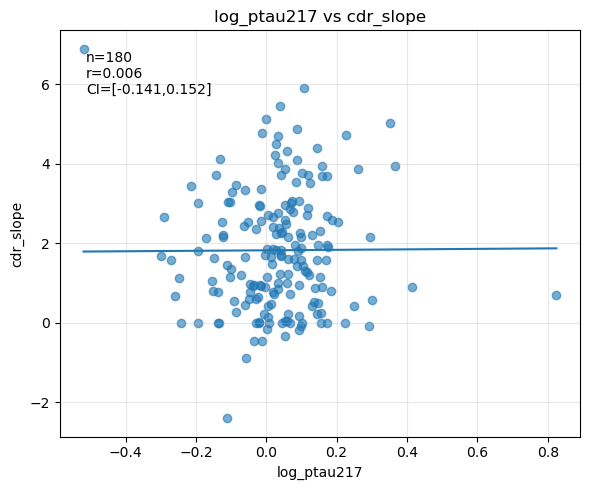

log_ptau217: n=180, r=0.0057, CI=(-0.1407,0.1518)


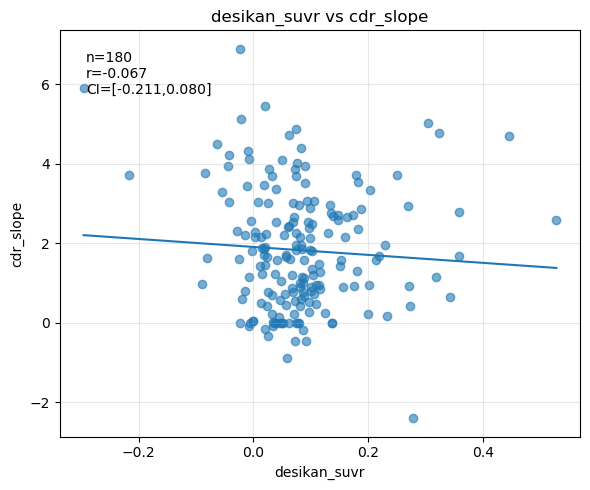

desikan_suvr: n=180, r=-0.0671, CI=(-0.2113,0.0799)


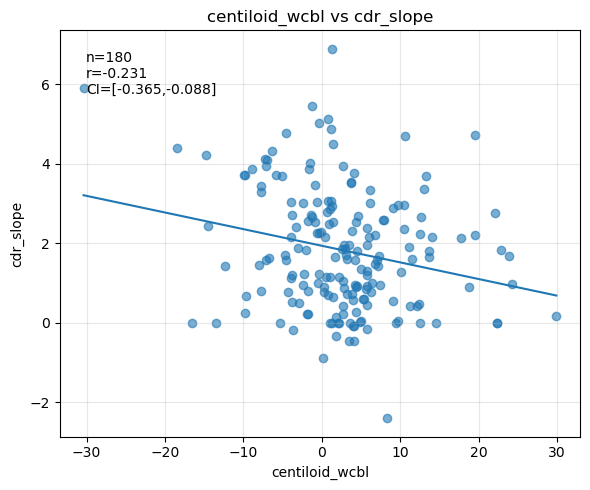

centiloid_wcbl: n=180, r=-0.2313, CI=(-0.3652,-0.0880)


In [197]:
plot_corr(df_slopes, "log_ptau217")
plot_corr(df_slopes, "desikan_suvr")
plot_corr(df_slopes, "centiloid_wcbl")

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress, norm

def fisher_ci(r, n, alpha=0.05):
    if n <= 3 or np.isnan(r):
        return np.nan, np.nan
    r = np.clip(r, -0.999999, 0.999999)
    z = np.arctanh(r)
    se = 1 / np.sqrt(n - 3)
    zcrit = norm.ppf(1 - alpha / 2)
    lo = np.tanh(z - zcrit * se)
    hi = np.tanh(z + zcrit * se)
    return lo, hi


def plot_corr_standardized(df_slopes, biomarker_col, outcome_col="cdr_slope"):
    
    tmp = df_slopes[[biomarker_col, outcome_col]].dropna()
    n = len(tmp)

    if n < 3:
        print(f"{biomarker_col}: not enough data (n={n})")
        return

    x = tmp[biomarker_col].values
    y = tmp[outcome_col].values

    if np.std(x) == 0 or np.std(y) == 0:
        print(f"{biomarker_col}: zero variance")
        return

    # --- STANDARDIZE ---
    xz = (x - np.mean(x)) / np.std(x)
    yz = (y - np.mean(y)) / np.std(y)

    fit = linregress(xz, yz)
    r = fit.rvalue
    lo, hi = fisher_ci(r, n)

    # plot
    plt.figure(figsize=(6, 5))
    plt.scatter(xz, yz, alpha=0.6)

    xs = np.linspace(xz.min(), xz.max(), 100)
    plt.plot(xs, fit.intercept + fit.slope * xs)

    plt.xlabel(f"{biomarker_col} (z)")
    plt.ylabel(f"{outcome_col} (z)")
    plt.title(f"{biomarker_col} vs {outcome_col} (standardized)")

    plt.text(
        0.05, 0.95,
        f"n={n}\nr={r:.3f}\nCI=[{lo:.3f},{hi:.3f}]",
        transform=plt.gca().transAxes,
        va="top"
    )

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"{biomarker_col}: n={n}, r={r:.4f}, CI=({lo:.4f},{hi:.4f})")

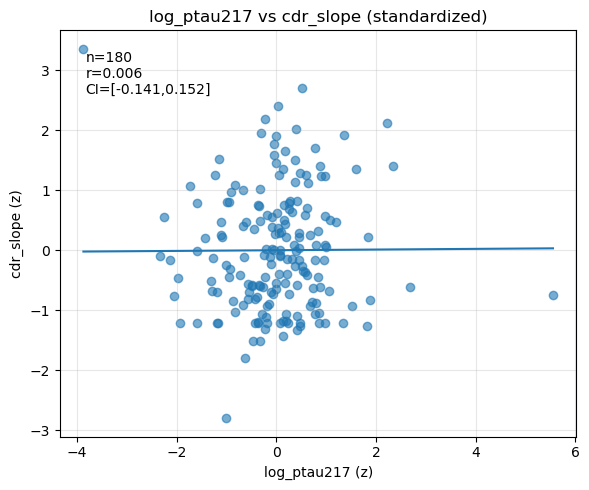

log_ptau217: n=180, r=0.0057, CI=(-0.1407,0.1518)


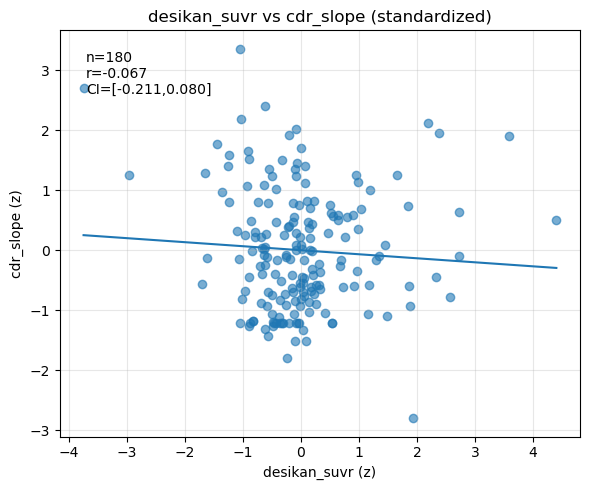

desikan_suvr: n=180, r=-0.0671, CI=(-0.2113,0.0799)


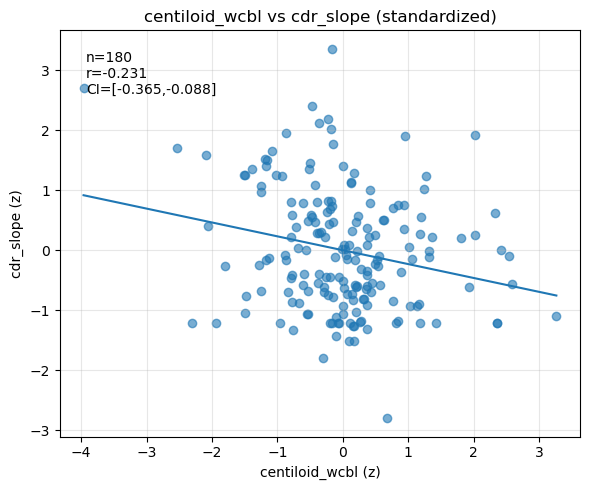

centiloid_wcbl: n=180, r=-0.2313, CI=(-0.3652,-0.0880)


In [57]:
plot_corr_standardized(df_slopes, "log_ptau217")
plot_corr_standardized(df_slopes, "desikan_suvr")
plot_corr_standardized(df_slopes, "centiloid_wcbl")

### moca

In [58]:

import statsmodels.formula.api as smf

def compute_slopes_lme(
    df,
    value_col,
    time_col,
    covariates=None,
    id_col="subject_label",
):

    df.dropna(subset=[value_col,time_col],inplace=True)
    # convert time to years
    df["time_years"] = df[time_col] / 365.25

    # uild formula
    formula = f"{value_col} ~ time_years"
    if covariates:
        formula += " + " + " + ".join(covariates)

    # fit mixed model (random intercept + slope)
    model = smf.mixedlm(
        formula,
        df,
        groups=df[id_col],
        re_formula="~time_years"
    )

    result = model.fit()

    # extract slopes
    fixed_slope = result.params["time_years"]

    slopes = []

    for sid, re in result.random_effects.items():
        # random slope component
        rand_slope = re.get("time_years", 0.0)

        subject_slope = fixed_slope + rand_slope
        slopes.append((sid, subject_slope))

    return pd.DataFrame(slopes, columns=[id_col, "slope"]), result